# Predicting House Prices with Linear Regression
**Track:** Data Analytics — Level 2, Task 1
**Objective:** Build and evaluate a linear regression model that predicts house prices from area, location, rooms, and age.

Dataset: `house_prices.csv` — synthetic housing data with Area, Bedrooms, Bathrooms, Age, Location, and Price.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9,5)

df = pd.read_csv("house_prices.csv")
df.head()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Location,Price
0,1707.0,2,2,16,Suburb,221200.0
1,3137.0,2,2,7,Downtown,454500.0
2,1984.0,2,2,5,Downtown,312200.0
3,2664.0,4,4,25,Suburb,325200.0
4,1699.0,3,2,8,Downtown,280700.0


## 1. EDA — Nulls, Stats, Target Distribution

Area_sqft    10
Bedrooms      0
Bathrooms     0
Age_years     0
Location      0
Price         0
dtype: int64
         Area_sqft    Bedrooms   Bathrooms   Age_years          Price
count   690.000000  700.000000  700.000000  700.000000     700.000000
mean   1842.213043    2.970000    2.610000   21.634286  257021.571429
std     638.654961    1.055248    1.103078   12.932994   87985.905884
min     400.000000    1.000000    1.000000    0.000000   50000.000000
25%    1413.750000    2.000000    2.000000   10.750000  192750.000000
50%    1822.500000    3.000000    3.000000   22.000000  257200.000000
75%    2291.000000    4.000000    3.000000   33.000000  319200.000000
max    3849.000000    5.000000    5.000000   44.000000  585800.000000


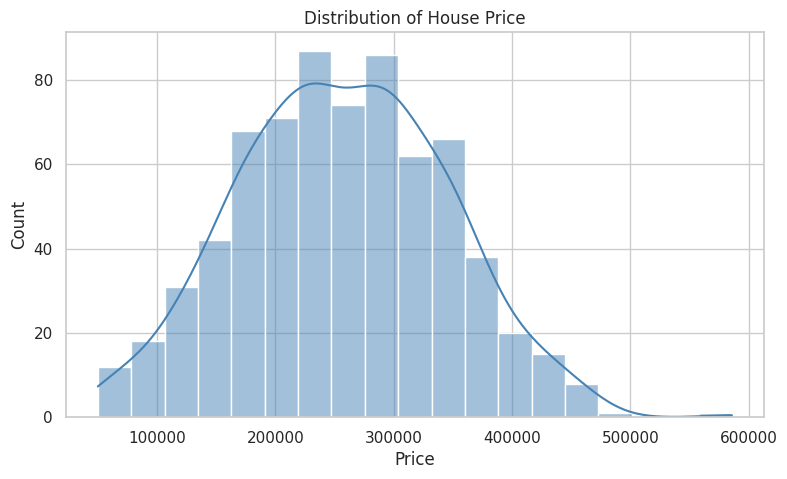

In [2]:
print(df.isnull().sum())
print(df.describe())

plt.figure()
sns.histplot(df["Price"], kde=True, color="steelblue")
plt.title("Distribution of House Price")
plt.show()

**Observation:** `Area_sqft` has a few missing values. `Price` is roughly normal with a slight right skew, as expected for real-estate prices.

## 2. Feature Selection Discussion

We expect **Area_sqft** to be the strongest predictor (bigger homes cost more), followed by **Bedrooms/Bathrooms** (more rooms = more usable space),
**Age_years** (older homes typically sell for less, all else equal), and **Location**, since neighbourhood desirability shifts price independent of size.

## 3. Handle Missing Values & Encode Categoricals

In [3]:
df["Area_sqft"] = df["Area_sqft"].fillna(df["Area_sqft"].median())

df_encoded = pd.get_dummies(df, columns=["Location"], drop_first=True)
df_encoded.head()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Price,Location_Rural,Location_Suburb,Location_Uptown
0,1707.0,2,2,16,221200.0,False,True,False
1,3137.0,2,2,7,454500.0,False,False,False
2,1984.0,2,2,5,312200.0,False,False,False
3,2664.0,4,4,25,325200.0,False,True,False
4,1699.0,3,2,8,280700.0,False,False,False


## 4. Correlation Heatmap

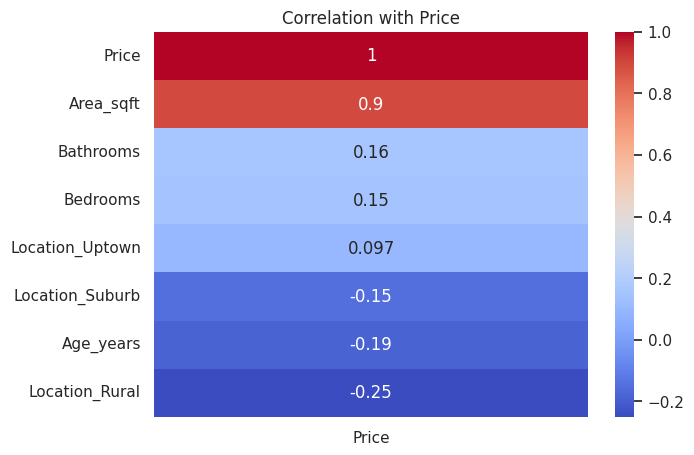

In [4]:
plt.figure(figsize=(7,5))
sns.heatmap(df_encoded.corr(numeric_only=True)[["Price"]].sort_values("Price", ascending=False), annot=True, cmap="coolwarm")
plt.title("Correlation with Price")
plt.show()

**Observation:** `Area_sqft` correlates most strongly with `Price`, confirming our feature-selection hypothesis; `Age_years` shows a negative correlation as expected.

## 5. Train/Test Split

In [5]:
X = df_encoded.drop(columns=["Price"])
y = df_encoded["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(560, 7) (140, 7)


## 6. Train Linear Regression

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Model trained.")

Model trained.


## 7. Evaluation

In [7]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2:   {r2:.4f}")

MSE:  498,828,673.38
RMSE: 22,334.47
R2:   0.9306


**Observation:** An R² in the ~0.8-0.95 range means the model explains most of the price variance using just these features — a strong result for a first linear model.

## 8. Actual vs Predicted

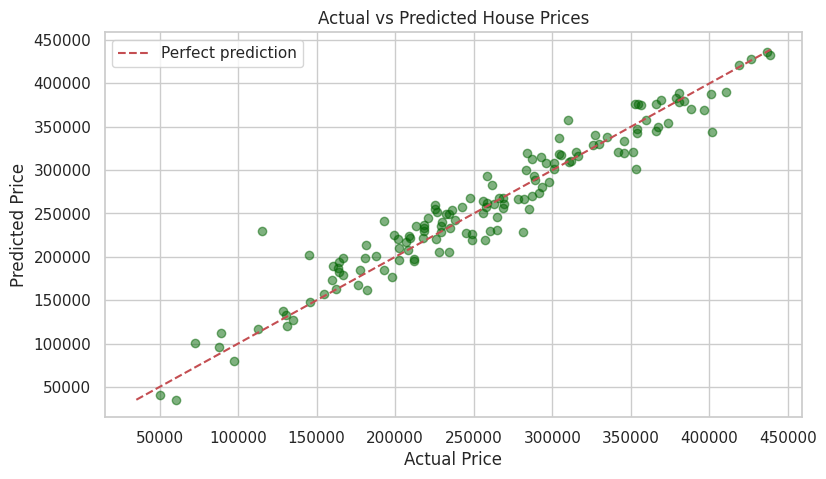

In [8]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5, color="darkgreen")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()

## 9. Residual Plot

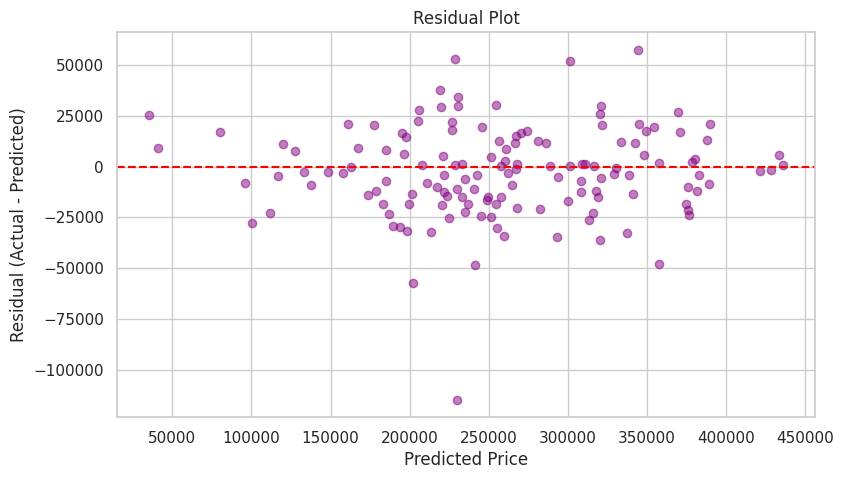

In [9]:
residuals = y_test - y_pred
plt.figure()
plt.scatter(y_pred, residuals, alpha=0.5, color="purple")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

**Observation:** Residuals scatter randomly around zero with no funnel or curve shape, indicating the linear model's assumptions are reasonably satisfied.

## 10. Coefficient Analysis

In [10]:
coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": lr.coef_}).sort_values("Coefficient", ascending=False)
coef_df

,Feature,Coefficient
2,Bathrooms,6153.810601
1,Bedrooms,5529.866696
0,Area_sqft,121.112276
3,Age_years,-924.459468
6,Location_Uptown,-14139.096065
5,Location_Suburb,-40387.374788
4,Location_Rural,-74792.534102


**Observation:** `Area_sqft` has the largest positive coefficient (each additional sq ft adds a fixed dollar amount to predicted price), while `Age_years` is negative, confirming older homes are valued lower, holding other features constant.

## 11. Bonus — Ridge & Lasso Comparison

In [11]:
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=100.0).fit(X_train, y_train)

for name, model in [("Linear", lr), ("Ridge", ridge), ("Lasso", lasso)]:
    pred = model.predict(X_test)
    print(f"{name}: RMSE={np.sqrt(mean_squared_error(y_test, pred)):,.0f}  R2={r2_score(y_test, pred):.4f}")

Linear: RMSE=22,334  R2=0.9306
Ridge: RMSE=22,354  R2=0.9305
Lasso: RMSE=22,376  R2=0.9303


## Conclusion
The Linear Regression model achieves strong predictive performance using Area, Bedrooms, Bathrooms, Age, and Location.
Ridge and Lasso regularisation produce very similar results here since multicollinearity between features is low — Linear Regression's simplicity and interpretability make it the practical choice for this dataset.